Flagging Vendor invoices for Manual review

In [1]:
import sqlite3
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt


In [4]:
# connect to the database
# connect to sql database
from pathlib import Path
db_path = Path(r"D:\invoice_intelligent_pro\data\inventory.db")
db_path.parent.mkdir(parents=True, exist_ok=True)

conn = sqlite3.connect(db_path)

In [5]:
tables = pd.read_sql_query(
    "SELECT name FROM sqlite_master WHERE type = 'table'",
    conn
)

print(tables)

              name
0        purchases
1  purchase_prices
2   vendor_invoice
3  begin_inventory
4    end_inventory


In [6]:
for table in tables['name']: 
    print("table Name", table)
    df = pd.read_sql_query(f"select * from {table} limit 5",conn)
    display(df)

table Name purchases


,InventoryId,Store,Brand,Description,Size,VendorNumber,VendorName,PONumber,PODate,ReceivingDate,InvoiceDate,PayDate,PurchasePrice,Quantity,Dollars,Classification
0,69_MOUNTMEND_8412,69,8412,Tequila Ocho Plata Fresno,750mL,105,ALTAMAR BRANDS LLC,8124,2023-12-21,2024-01-02,2024-01-04,2024-02-16,35.71,6,214.26,1
1,30_CULCHETH_5255,30,5255,TGI Fridays Ultimte Mudslide,1.75L,4466,AMERICAN VINTAGE BEVERAGE,8137,2023-12-22,2024-01-01,2024-01-07,2024-02-21,9.35,4,37.40,1
2,34_PITMERDEN_5215,34,5215,TGI Fridays Long Island Iced,1.75L,4466,AMERICAN VINTAGE BEVERAGE,8137,2023-12-22,2024-01-02,2024-01-07,2024-02-21,9.41,5,47.05,1
3,1_HARDERSFIELD_5255,1,5255,TGI Fridays Ultimte Mudslide,1.75L,4466,AMERICAN VINTAGE BEVERAGE,8137,2023-12-22,2024-01-01,2024-01-07,2024-02-21,9.35,6,56.10,1
4,76_DONCASTER_2034,76,2034,Glendalough Double Barrel,750mL,388,ATLANTIC IMPORTING COMPANY,8169,2023-12-24,2024-01-02,2024-01-09,2024-02-16,21.32,5,106.60,1


table Name purchase_prices


,Brand,Description,Price,Size,Volume,Classification,PurchasePrice,VendorNumber,VendorName
0,58,Gekkeikan Black & Gold Sake,12.99,750mL,750,1,9.28,8320,SHAW ROSS INT L IMP LTD
1,62,Herradura Silver Tequila,36.99,750mL,750,1,28.67,1128,BROWN-FORMAN CORP
2,63,Herradura Reposado Tequila,38.99,750mL,750,1,30.46,1128,BROWN-FORMAN CORP
3,72,No. 3 London Dry Gin,34.99,750mL,750,1,26.11,9165,ULTRA BEVERAGE COMPANY LLP
4,75,Three Olives Tomato Vodka,14.99,750mL,750,1,10.94,7245,PROXIMO SPIRITS INC.


table Name vendor_invoice


,VendorNumber,VendorName,InvoiceDate,PONumber,PODate,PayDate,Quantity,Dollars,Freight,Approval
0,105,ALTAMAR BRANDS LLC,2024-01-04,8124,2023-12-21,2024-02-16,6,214.26,3.47,None
1,4466,AMERICAN VINTAGE BEVERAGE,2024-01-07,8137,2023-12-22,2024-02-21,15,140.55,8.57,None
2,388,ATLANTIC IMPORTING COMPANY,2024-01-09,8169,2023-12-24,2024-02-16,5,106.60,4.61,None
3,480,BACARDI USA INC,2024-01-12,8106,2023-12-20,2024-02-05,10100,137483.78,2935.20,None
4,516,BANFI PRODUCTS CORP,2024-01-07,8170,2023-12-24,2024-02-12,1935,15527.25,429.20,None


table Name begin_inventory


,InventoryId,Store,City,Brand,Description,Size,onHand,Price,startDate
0,1_HARDERSFIELD_58,1,HARDERSFIELD,58,Gekkeikan Black & Gold Sake,750mL,8,12.99,2024-01-01
1,1_HARDERSFIELD_60,1,HARDERSFIELD,60,Canadian Club 1858 VAP,750mL,7,10.99,2024-01-01
2,1_HARDERSFIELD_62,1,HARDERSFIELD,62,Herradura Silver Tequila,750mL,6,36.99,2024-01-01
3,1_HARDERSFIELD_63,1,HARDERSFIELD,63,Herradura Reposado Tequila,750mL,3,38.99,2024-01-01
4,1_HARDERSFIELD_72,1,HARDERSFIELD,72,No. 3 London Dry Gin,750mL,6,34.99,2024-01-01


table Name end_inventory


,InventoryId,Store,City,Brand,Description,Size,onHand,Price,endDate
0,1_HARDERSFIELD_58,1,HARDERSFIELD,58,Gekkeikan Black & Gold Sake,750mL,11,12.99,2024-12-31
1,1_HARDERSFIELD_62,1,HARDERSFIELD,62,Herradura Silver Tequila,750mL,7,36.99,2024-12-31
2,1_HARDERSFIELD_63,1,HARDERSFIELD,63,Herradura Reposado Tequila,750mL,7,38.99,2024-12-31
3,1_HARDERSFIELD_72,1,HARDERSFIELD,72,No. 3 London Dry Gin,750mL,4,34.99,2024-12-31
4,1_HARDERSFIELD_75,1,HARDERSFIELD,75,Three Olives Tomato Vodka,750mL,7,14.99,2024-12-31


In [14]:
purchase_agg_df = pd.read_sql_query(""" 
                  select 
                  p.PONumber, 
                  count(distinct p.Brand) as total_brands,
                  sum(p.Quantity) as total_item_quantity,
                  sum(p.Dollars) as total_item_dollars,
                  avg(julianday(p.ReceivingDate)- julianday(p.PODate)) as avg_receiveing_delay
                  from purchases p
                  group by p.PONumber""", conn)

In [10]:
purchase_agg_df.head()

,PONumber,total_brands,total_item_quantity,total_item_dollars,avg_receiveing_delay
0,8106,81,10100,137483.78,12.614130
1,8107,2,24,348.72,12.500000
2,8108,165,8466,60281.13,12.632479
3,8109,23,2246,14298.09,12.626866
4,8110,183,8086,56493.23,12.695271


In [17]:
invoice_df = pd.read_sql_query(
    """
    SELECT
        vi.Quantity AS invoice_quantity,
        vi.Dollars AS invoice_dollars,
        vi.Freight,
        julianday(vi.InvoiceDate) - julianday(vi.PODate)
            AS days_po_to_invoice,
        julianday(vi.PayDate) - julianday(vi.InvoiceDate)
            AS days_to_pay
    FROM vendor_invoice AS vi
    """,
    conn
)

In [ ]:
# merge query
merged_df = pd.read_sql_query(
    """
    SELECT
        vi.PONumber,
        vi.Quantity AS invoice_quantity,
        vi.Dollars AS invoice_dollars,
        vi.Freight,
        julianday(vi.InvoiceDate) - julianday(vi.PODate)
            AS days_po_to_invoice,
        julianday(vi.PayDate) - julianday(vi.InvoiceDate)
            AS days_to_pay,
        p.total_brands,
        p.total_item_quantity,
        p.total_item_dollars,
        p.avg_receiving_delay
    FROM vendor_invoice AS vi
    LEFT JOIN (
        SELECT
            PONumber,
            COUNT(DISTINCT Brand) AS total_brands,
            SUM(Quantity) AS total_item_quantity,
            SUM(Dollars) AS total_item_dollars,
            AVG(
                julianday(ReceivingDate) - julianday(PODate)
            ) AS avg_receiving_delay
        FROM purchases
        GROUP BY PONumber
    ) AS p
        ON vi.PONumber = p.PONumber
    """,
    conn
)

display(merged_df.head())

,PONumber,invoice_quantity,invoice_dollars,Freight,days_po_to_invoice,days_to_pay,total_brands,total_item_quantity,total_item_dollars,avg_receiving_delay
0,8124,6,214.26,3.47,14.0,43.0,1,6,214.26,12.000000
1,8137,15,140.55,8.57,16.0,45.0,2,15,140.55,10.333333
2,8169,5,106.60,4.61,16.0,38.0,1,5,106.60,9.000000
3,8106,10100,137483.78,2935.20,23.0,24.0,81,10100,137483.78,12.614130
4,8170,1935,15527.25,429.20,14.0,36.0,29,1935,15527.25,8.752809


In [21]:
def invoice_risk_label(
    row,
    quantity_tolerance=0.10,
    dollars_tolerance=0.10,
    late_invoice_days=30,
    late_payment_days=30,
):
    """Assign a manual-review risk label to one merged invoice row."""
    risk_reasons = []

    if pd.isna(row["total_item_quantity"]):
        risk_reasons.append("missing_purchase_match")
    elif row["total_item_quantity"] == 0:
        risk_reasons.append("zero_purchase_quantity")
    elif abs(
        row["invoice_quantity"] - row["total_item_quantity"]
    ) / row["total_item_quantity"] > quantity_tolerance:
        risk_reasons.append("quantity_mismatch")

    if pd.isna(row["total_item_dollars"]):
        risk_reasons.append("missing_purchase_match")
    elif row["total_item_dollars"] == 0:
        risk_reasons.append("zero_purchase_dollars")
    elif abs(
        row["invoice_dollars"] - row["total_item_dollars"]
    ) / row["total_item_dollars"] > dollars_tolerance:
        risk_reasons.append("dollars_mismatch")

    if (
        pd.notna(row["days_po_to_invoice"])
        and row["days_po_to_invoice"] > late_invoice_days
    ):
        risk_reasons.append("late_invoice")

    if (
        pd.notna(row["days_to_pay"])
        and row["days_to_pay"] > late_payment_days
    ):
        risk_reasons.append("late_payment")

    if len(risk_reasons) >= 2:
        return "High"
    if risk_reasons:
        return "Medium"
    return "Low"


merged_df["invoice_risk_label"] = merged_df.apply(invoice_risk_label, axis=1)
merged_df["risk_reason_count"] = merged_df.apply(
    lambda row: int(row["invoice_risk_label"] != "Low"),
    axis=1,
)

display(
    merged_df[
        ["PONumber", "invoice_risk_label", "risk_reason_count"]
    ].head()
)
merged_df["invoice_risk_label"].value_counts()

,PONumber,invoice_risk_label,risk_reason_count
0,8124,Medium,1
1,8137,Medium,1
2,8169,Medium,1
3,8106,Low,0
4,8170,Medium,1


invoice_risk_label
Medium    3246
High      1322
Low        975
Name: count, dtype: int64

In [27]:
correlation_matrix = merged_df.corr(numeric_only=True)
display(correlation_matrix)

,PONumber,invoice_quantity,invoice_dollars,Freight,days_po_to_invoice,days_to_pay,total_brands,total_item_quantity,total_item_dollars,avg_receiving_delay,risk_reason_count
PONumber,1.000000,0.049230,0.058917,0.043617,-0.002234,0.012558,0.013423,0.049442,0.059221,-0.042362,0.183681
invoice_quantity,0.049230,1.000000,0.963831,0.946550,0.000526,0.022284,0.566394,0.706117,0.668171,0.000519,0.016161
invoice_dollars,0.058917,0.963831,1.000000,0.985141,0.001610,0.025661,0.536952,0.667666,0.679537,0.004694,0.020156
Freight,0.043617,0.946550,0.985141,1.000000,0.003265,0.025513,0.536381,0.656616,0.670768,0.015645,0.017416
days_po_to_invoice,-0.002234,0.000526,0.001610,0.003265,1.000000,-0.370432,0.009519,0.005543,0.007931,0.515538,-0.256411
days_to_pay,0.012558,0.022284,0.025661,0.025513,-0.370432,1.000000,0.020336,0.016203,0.015610,-0.029403,0.618321
total_brands,0.013423,0.566394,0.536952,0.536381,0.009519,0.020336,1.000000,0.783825,0.753092,0.000496,0.009742
total_item_quantity,0.049442,0.706117,0.667666,0.656616,0.005543,0.016203,0.783825,1.000000,0.963831,-0.014016,0.016161
total_item_dollars,0.059221,0.668171,0.679537,0.670768,0.007931,0.015610,0.753092,0.963831,1.000000,-0.014251,0.020156
avg_receiving_delay,-0.042362,0.000519,0.004694,0.015645,0.515538,-0.029403,0.000496,-0.014016,-0.014251,1.000000,-0.028463


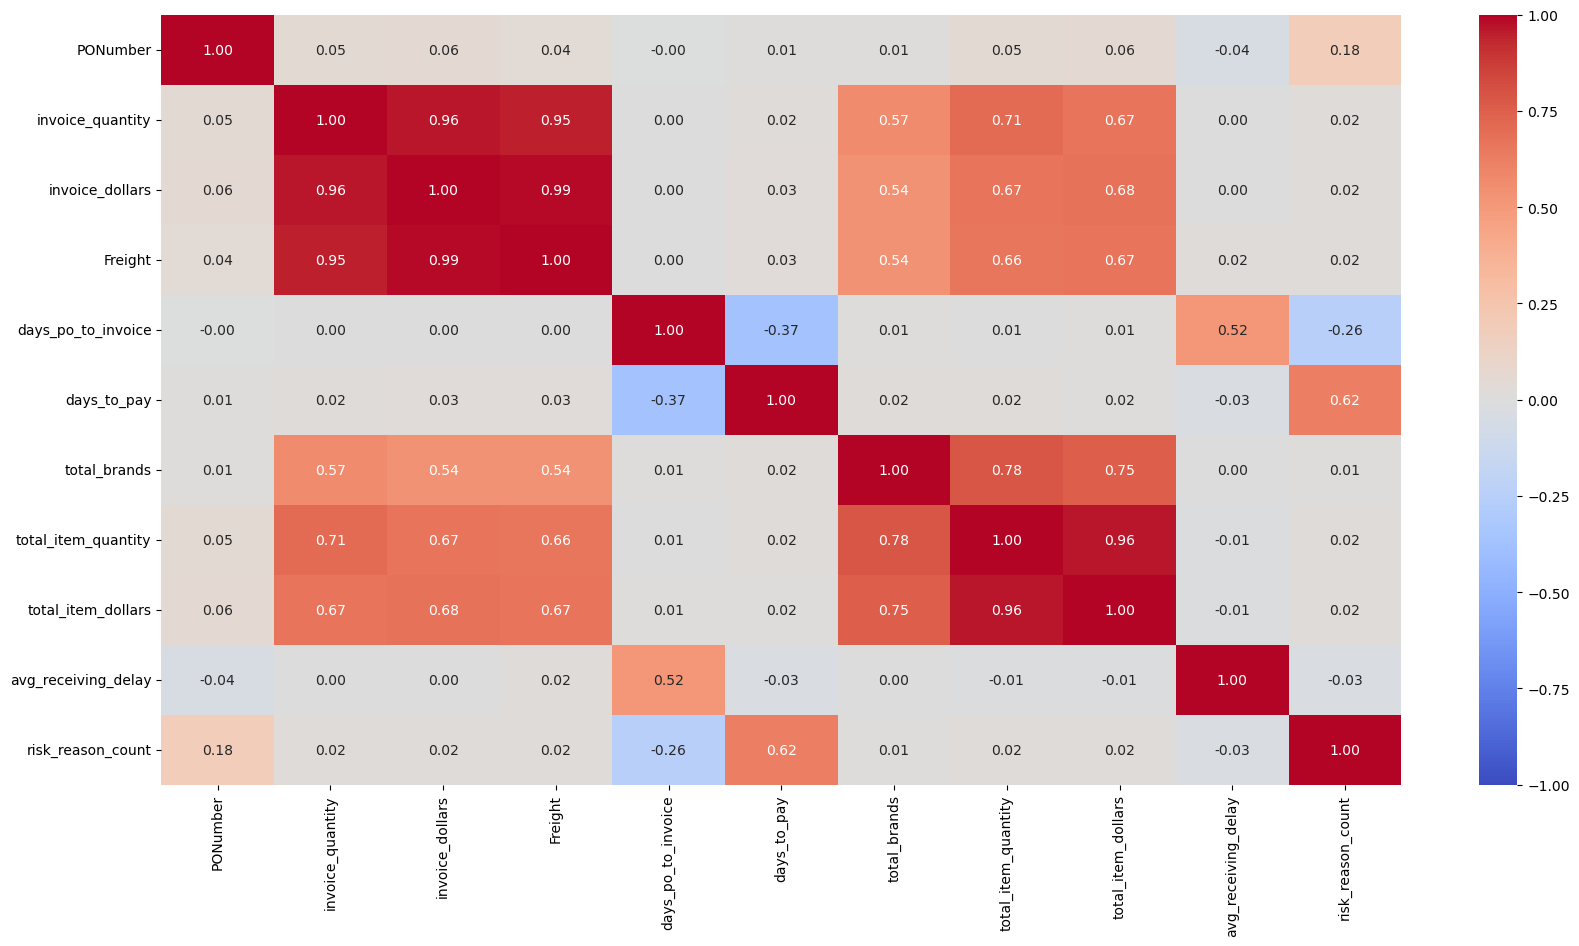

In [29]:
plt.figure(figsize=(20,10))
sns.heatmap(
    correlation_matrix,
    annot=True,
    cmap="coolwarm",
    fmt=".2f",
    vmin=-1,
    vmax=1
)
plt.show()

In [30]:
flagged_invoices = merged_df[
    merged_df["invoice_risk_label"].isin(["High", "Medium"])
].copy()

normal_invoices = merged_df[
    merged_df["invoice_risk_label"] == "Low"
].copy()

print(f"Flagged invoices: {len(flagged_invoices)}")
print(f"Normal invoices: {len(normal_invoices)}")

print("\nFlagged invoices:")
display(
    flagged_invoices[
        ["PONumber", "invoice_risk_label", "risk_reason_count"]
    ].head()
)

print("Normal invoices:")
display(
    normal_invoices[
        ["PONumber", "invoice_risk_label", "risk_reason_count"]
    ].head()
)

Flagged invoices: 4568
Normal invoices: 975

Flagged invoices:


,PONumber,invoice_risk_label,risk_reason_count
0,8124,Medium,1
1,8137,Medium,1
2,8169,Medium,1
4,8170,Medium,1
6,8150,Medium,1


Normal invoices:


,PONumber,invoice_risk_label,risk_reason_count
3,8106,Low,0
5,8191,Low,0
7,8171,Low,0
12,8125,Low,0
14,8108,Low,0


In [33]:
from scipy.stats import ttest_ind

numeric_columns = [
    "invoice_quantity",
    "invoice_dollars",
    "Freight",
    "days_po_to_invoice",
    "days_to_pay",
    "total_item_quantity",
    "total_item_dollars",
    "avg_receiving_delay",
]

stats_results = []

for column in numeric_columns:
    flagged_values = flagged_invoices[column].dropna()
    normal_values = normal_invoices[column].dropna()

    if len(flagged_values) < 2 or len(normal_values) < 2:
        continue

    t_statistic, p_value = ttest_ind(
        flagged_values,
        normal_values,
        equal_var=False,
    )

    stats_results.append(
        {
            "Feature": column,
            "Flagged_Mean": flagged_values.mean(),
            "Normal_Mean": normal_values.mean(),
            "t_statistic": t_statistic,
            "p_value": p_value,
            "Significant_at_0.05": p_value < 0.05,
        }
    )

stats_results_df = pd.DataFrame(stats_results)

significant_results_df = stats_results_df[
    stats_results_df["p_value"] < 0.05
].sort_values("p_value").reset_index(drop=True)

significant_features = significant_results_df["Feature"].tolist()

print("Significant features:", significant_features)
display(significant_results_df)

Significant features: ['days_to_pay', 'days_po_to_invoice', 'avg_receiving_delay']


,Feature,Flagged_Mean,Normal_Mean,t_statistic,p_value,Significant_at_0.05
0,days_to_pay,37.137259,27.650256,97.139995,0.000000e+00,True
1,days_po_to_invoice,16.054072,18.160000,-21.606319,7.012234e-91,True
2,avg_receiving_delay,7.647552,7.783935,-2.079375,3.776540e-02,True


In [ ]:
X = merged_df[significant_features].copy()
y = merged_df["invoice_risk_label"].copy()

print("X columns:", X.columns.tolist())
print("X shape:", X.shape)
print("y shape:", y.shape)
print("Risk labels:")
print(y.value_counts())

X columns: ['days_to_pay', 'days_po_to_invoice', 'avg_receiving_delay']
X shape: (5543, 3)
y shape: (5543,)
Risk labels:
invoice_risk_label
Medium    3246
High      1322
Low        975
Name: count, dtype: int64


In [40]:
model_data = merged_df.copy()

purchase_quantity = model_data["total_item_quantity"].replace(0, pd.NA)
purchase_dollars = model_data["total_item_dollars"].replace(0, pd.NA)

model_data["quantity_difference_pct"] = (
    (model_data["invoice_quantity"] - model_data["total_item_quantity"]).abs()
    / purchase_quantity
).fillna(1.0)

model_data["dollars_difference_pct"] = (
    (model_data["invoice_dollars"] - model_data["total_item_dollars"]).abs()
    / purchase_dollars
).fillna(1.0)

model_data["missing_purchase_match"] = (
    model_data["total_item_quantity"].isna()
    | model_data["total_item_dollars"].isna()
).astype(int)

model_data["late_invoice_flag"] = (
    model_data["days_po_to_invoice"] > 30
).fillna(False).astype(int)

model_data["late_payment_flag"] = (
    model_data["days_to_pay"] > 30
).fillna(False).astype(int)

feature_columns = [
    "days_to_pay",
    "days_po_to_invoice",
    "avg_receiving_delay",
    "quantity_difference_pct",
    "dollars_difference_pct",
    "missing_purchase_match",
    "late_invoice_flag",
    "late_payment_flag",
]

X = model_data[feature_columns].copy()
y = model_data["invoice_risk_label"].copy()

print("X columns:", X.columns.tolist())
print("X shape:", X.shape)
print("y shape:", y.shape)
print("Risk labels:")
print(y.value_counts())

X columns: ['days_to_pay', 'days_po_to_invoice', 'avg_receiving_delay', 'quantity_difference_pct', 'dollars_difference_pct', 'missing_purchase_match', 'late_invoice_flag', 'late_payment_flag']
X shape: (5543, 8)
y shape: (5543,)
Risk labels:
invoice_risk_label
Medium    3246
High      1322
Low        975
Name: count, dtype: int64


In [41]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, MinMaxScaler

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y,
)

scaler = MinMaxScaler()

X_train_scaled = pd.DataFrame(
    scaler.fit_transform(X_train),
    columns=X_train.columns,
    index=X_train.index,
)

X_test_scaled = pd.DataFrame(
    scaler.transform(X_test),
    columns=X_test.columns,
    index=X_test.index,
)

print("X_train_scaled shape:", X_train_scaled.shape)
print("X_test_scaled shape:", X_test_scaled.shape)
display(X_train_scaled.head())

X_train_scaled shape: (4434, 8)
X_test_scaled shape: (1109, 8)


,days_to_pay,days_po_to_invoice,avg_receiving_delay,quantity_difference_pct,dollars_difference_pct,missing_purchase_match,late_invoice_flag,late_payment_flag
3156,0.08,0.714286,0.511628,0.0,0.0,0.0,0.0,0.0
298,0.40,0.714286,0.499231,0.0,0.0,0.0,0.0,1.0
1886,0.48,0.571429,0.625000,0.0,0.0,0.0,0.0,1.0
4025,0.56,0.642857,0.642105,0.0,0.0,0.0,0.0,1.0
1214,0.60,0.857143,0.611765,0.0,0.0,0.0,0.0,1.0


In [42]:
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report

model_1 = LogisticRegression(max_iter=1000, random_state=42)
model_2 = DecisionTreeClassifier(max_depth=5, random_state=42)
model_3 = RandomForestClassifier(
    n_estimators=100,
    max_depth=5,
    random_state=42,
)

model_1.fit(X_train_scaled, y_train)
model_2.fit(X_train_scaled, y_train)
model_3.fit(X_train_scaled, y_train)

models = {
    "Logistic Regression": model_1,
    "Decision Tree Classifier": model_2,
    "Random Forest Classifier": model_3,
}

classification_results = []

for model_name, model in models.items():
    predictions = model.predict(X_test_scaled)
    accuracy = accuracy_score(y_test, predictions)

    classification_results.append(
        {
            "Model": model_name,
            "Accuracy": accuracy,
        }
    )

    print(f"\n{model_name}")
    print(f"Accuracy: {accuracy:.4f}")
    print(classification_report(y_test, predictions, zero_division=0))

classification_results_df = pd.DataFrame(classification_results)
display(classification_results_df.sort_values("Accuracy", ascending=False))


Logistic Regression
Accuracy: 0.7638
              precision    recall  f1-score   support

        High       1.00      0.02      0.04       265
         Low       0.80      1.00      0.89       195
      Medium       0.75      1.00      0.86       649

    accuracy                           0.76      1109
   macro avg       0.85      0.67      0.59      1109
weighted avg       0.82      0.76      0.67      1109


Decision Tree Classifier
Accuracy: 0.9991
              precision    recall  f1-score   support

        High       1.00      1.00      1.00       265
         Low       1.00      1.00      1.00       195
      Medium       1.00      1.00      1.00       649

    accuracy                           1.00      1109
   macro avg       1.00      1.00      1.00      1109
weighted avg       1.00      1.00      1.00      1109


Random Forest Classifier
Accuracy: 0.9982
              precision    recall  f1-score   support

        High       0.99      1.00      1.00       265
     

,Model,Accuracy
1,Decision Tree Classifier,0.999098
2,Random Forest Classifier,0.998197
0,Logistic Regression,0.763751


                   Feature  Importance
4   dollars_difference_pct    0.306796
3  quantity_difference_pct    0.281154
7        late_payment_flag    0.205413
0              days_to_pay    0.190281
1       days_po_to_invoice    0.013548
2      avg_receiving_delay    0.002808
5   missing_purchase_match    0.000000
6        late_invoice_flag    0.000000


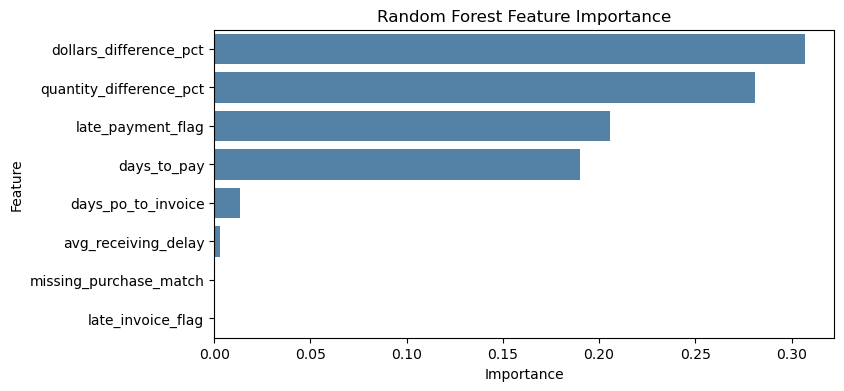

In [43]:
feature_importance_df = pd.DataFrame(
    {
        "Feature": X.columns,
        "Importance": model_3.feature_importances_,
    }
).sort_values("Importance", ascending=False)

print(feature_importance_df)

plt.figure(figsize=(8, 4))
sns.barplot(
    data=feature_importance_df,
    x="Importance",
    y="Feature",
    color="steelblue",
)
plt.title("Random Forest Feature Importance")
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.show()

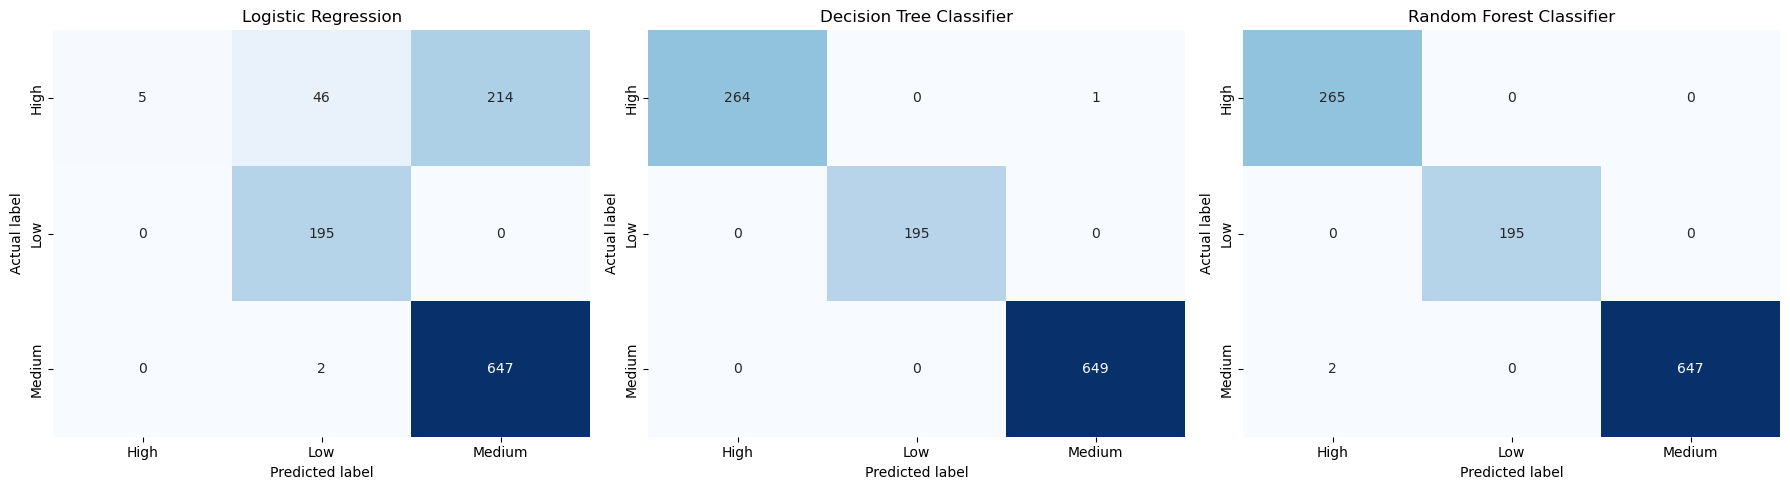

In [44]:
from sklearn.metrics import confusion_matrix

class_labels = sorted(y_test.unique())

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for axis, (model_name, model) in zip(axes, models.items()):
    predictions = model.predict(X_test_scaled)
    matrix = confusion_matrix(
        y_test,
        predictions,
        labels=class_labels,
    )

    sns.heatmap(
        matrix,
        annot=True,
        fmt="d",
        cmap="Blues",
        cbar=False,
        xticklabels=class_labels,
        yticklabels=class_labels,
        ax=axis,
    )
    axis.set_title(model_name)
    axis.set_xlabel("Predicted label")
    axis.set_ylabel("Actual label")

plt.tight_layout()
plt.show()